# JS Construcciones - Exploratory Data Analysis

Exploratory analysis of the construction company's financial data.

**Data source:** DuckDB warehouse (extracted from Airtable)  
**Period:** July 2024 - January 2026  
**Currency:** PYG (Paraguayan Guaraní)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Connect to DuckDB warehouse
DB_PATH = Path('../../warehouse/js_construcciones.duckdb')
con = duckdb.connect(str(DB_PATH), read_only=True)

# Quick check: list all schemas and tables
con.sql("SELECT schema_name, table_name, estimated_size FROM duckdb_tables() ORDER BY schema_name, table_name").show()

┌─────────────┬─────────────────────────────────┬────────────────┐
│ schema_name │           table_name            │ estimated_size │
│   varchar   │             varchar             │     int64      │
├─────────────┼─────────────────────────────────┼────────────────┤
│ main_marts  │ dim_obras_enriched              │             49 │
│ main_marts  │ fct_costo_por_rubro             │            252 │
│ main_marts  │ fct_desviacion_presupuesto      │            252 │
│ main_marts  │ fct_gasto_por_obra              │             49 │
│ main_marts  │ fct_proveedor_analytics         │            346 │
│ main_marts  │ fct_tendencia_mensual           │             65 │
│ main_marts  │ fct_trabajador_analytics        │            118 │
│ raw         │ dim_clientes                    │              9 │
│ raw         │ dim_obras                       │             49 │
│ raw         │ dim_proveedores                 │            345 │
│ raw         │ dim_proveedores_personal        │            2

## 1. Data Overview

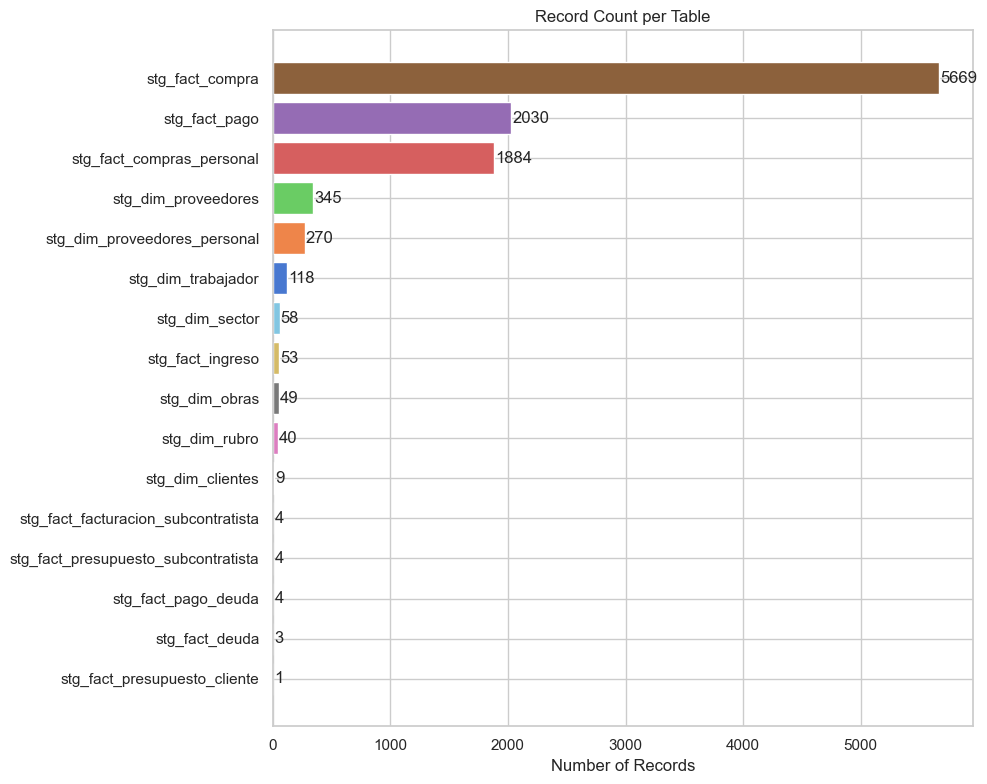


Total records: 10,541


In [2]:
# Record counts per table
tables = [
    'main_staging.stg_fact_compra', 'main_staging.stg_fact_pago', 'main_staging.stg_fact_ingreso',
    'main_staging.stg_fact_deuda', 'main_staging.stg_fact_pago_deuda',
    'main_staging.stg_fact_presupuesto_cliente', 'main_staging.stg_fact_presupuesto_subcontratista',
    'main_staging.stg_fact_facturacion_subcontratista', 'main_staging.stg_fact_compras_personal',
    'main_staging.stg_dim_obras', 'main_staging.stg_dim_clientes', 'main_staging.stg_dim_proveedores',
    'main_staging.stg_dim_proveedores_personal', 'main_staging.stg_dim_trabajador',
    'main_staging.stg_dim_rubro', 'main_staging.stg_dim_sector'
]

counts = []
for t in tables:
    try:
        n = con.sql(f'SELECT count(*) as n FROM {t}').fetchone()[0]
        counts.append({'table': t.split('.')[-1], 'rows': n})
    except:
        counts.append({'table': t.split('.')[-1], 'rows': 0})

df_counts = pd.DataFrame(counts).sort_values('rows', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_counts['table'], df_counts['rows'], color=sns.color_palette('muted'))
ax.set_xlabel('Number of Records')
ax.set_title('Record Count per Table')
for i, v in enumerate(df_counts['rows']):
    ax.text(v + 10, i, str(v), va='center')
plt.tight_layout()
plt.show()

print(f"\nTotal records: {df_counts['rows'].sum():,}")

## 2. Expense Distribution by Obra (Project)

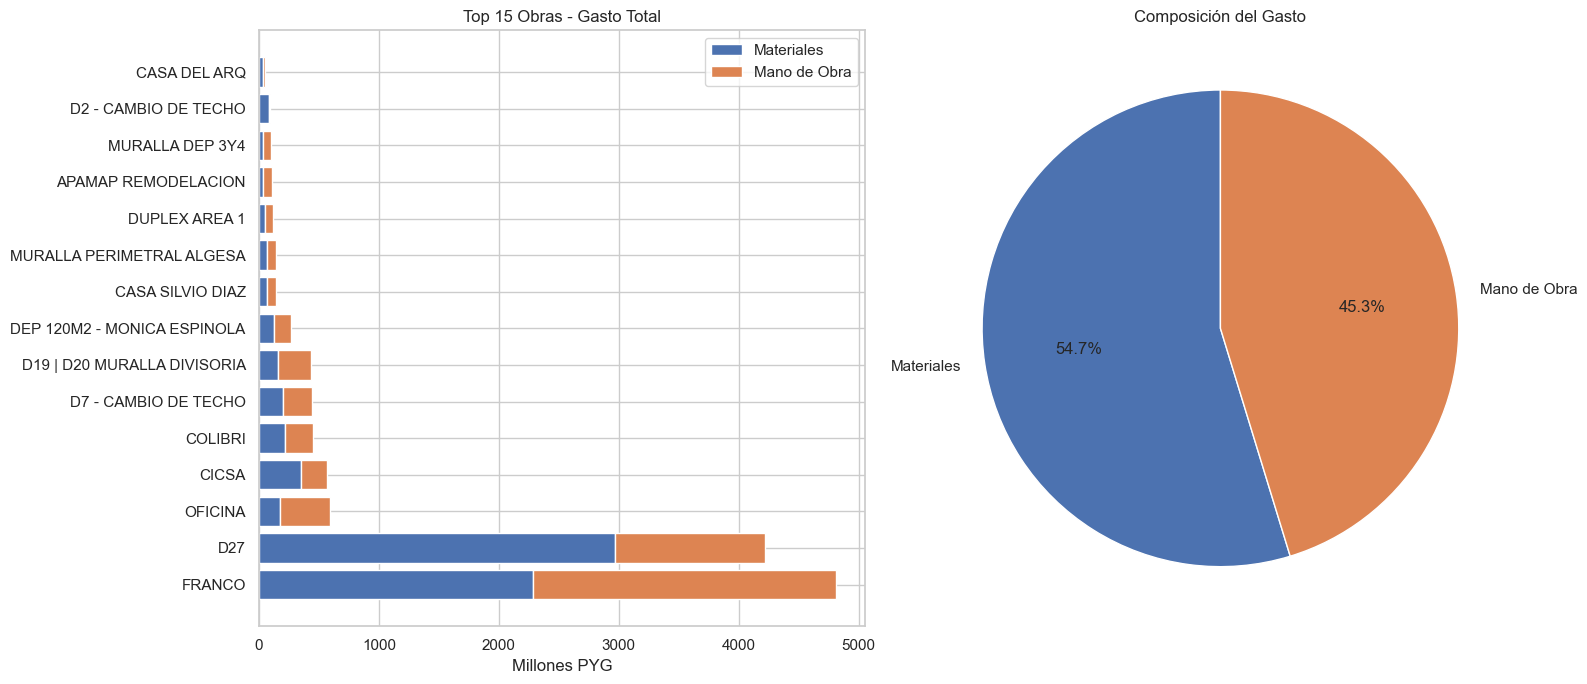

In [3]:
df_obras = con.sql("""
    SELECT obra_id, nombre_obra, total_materiales, total_mano_obra, total_gastos, total_ingresos, resultado_neto
    FROM main_marts.fct_gasto_por_obra
    ORDER BY total_gastos DESC
    LIMIT 15
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 projects by total spend
axes[0].barh(df_obras['nombre_obra'], df_obras['total_materiales'] / 1e6, label='Materiales', color='#4C72B0')
axes[0].barh(df_obras['nombre_obra'], df_obras['total_mano_obra'] / 1e6, 
             left=df_obras['total_materiales'] / 1e6, label='Mano de Obra', color='#DD8452')
axes[0].set_xlabel('Millones PYG')
axes[0].set_title('Top 15 Obras - Gasto Total')
axes[0].legend()

# Materials vs Labor ratio
total_mat = df_obras['total_materiales'].sum()
total_mo = df_obras['total_mano_obra'].sum()
axes[1].pie([total_mat, total_mo], labels=['Materiales', 'Mano de Obra'], 
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Composición del Gasto')

plt.tight_layout()
plt.show()

## 3. Monthly Expense Trend

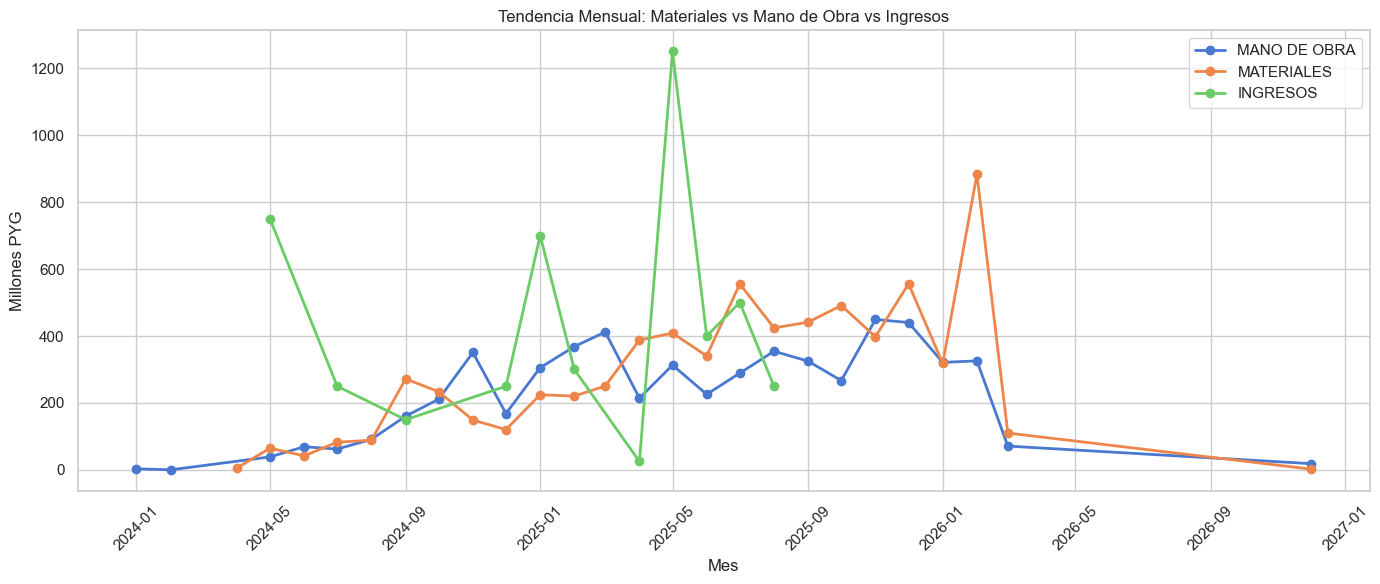

In [4]:
df_trend = con.sql("""
    SELECT mes, tipo_gasto, monto
    FROM main_marts.fct_tendencia_mensual
    ORDER BY mes
""").df()

df_trend['mes'] = pd.to_datetime(df_trend['mes'])

fig, ax = plt.subplots(figsize=(14, 6))
for tipo in df_trend['tipo_gasto'].unique():
    subset = df_trend[df_trend['tipo_gasto'] == tipo]
    ax.plot(subset['mes'], subset['monto'] / 1e6, marker='o', label=tipo, linewidth=2)

ax.set_xlabel('Mes')
ax.set_ylabel('Millones PYG')
ax.set_title('Tendencia Mensual: Materiales vs Mano de Obra vs Ingresos')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Supplier Pareto Analysis (80/20)

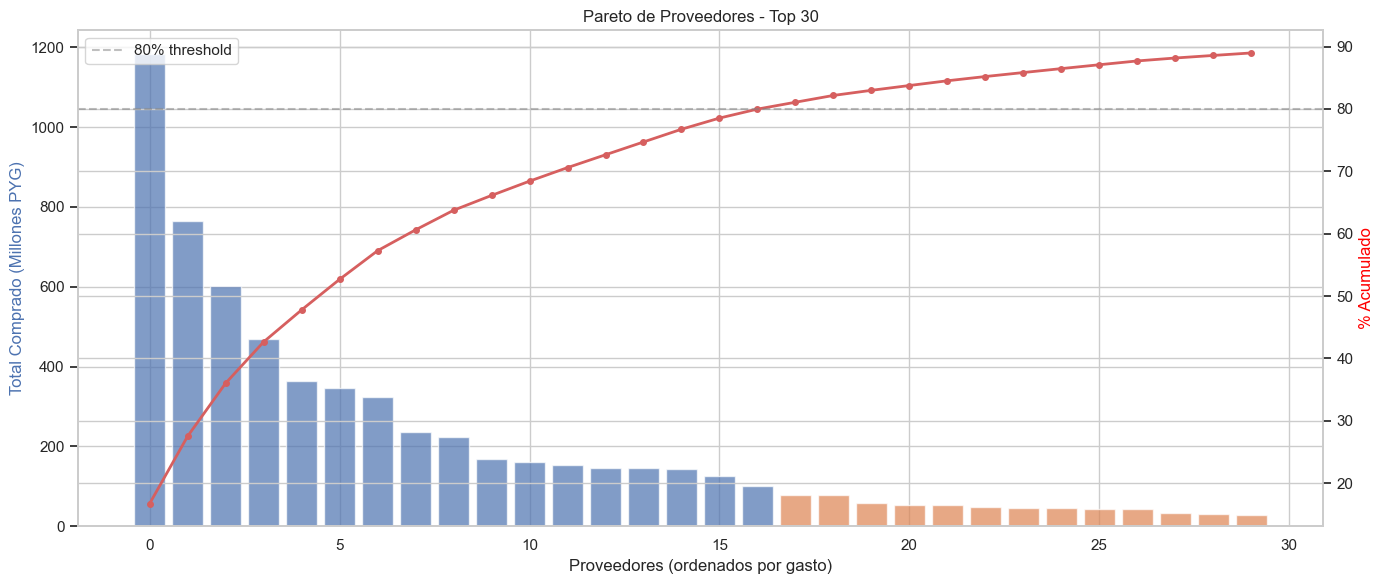

A (80%): 17 proveedores (4.9%) = 5656M PYG
B (15%): 36 proveedores (10.4%) = 1053M PYG
C (5%): 293 proveedores (84.7%) = 364M PYG


In [5]:
df_pareto = con.sql("""
    SELECT proveedor_id, total_comprado, pct_del_total, pct_acumulado, clasificacion_pareto
    FROM main_marts.fct_proveedor_analytics
    ORDER BY ranking
""").df()

fig, ax1 = plt.subplots(figsize=(14, 6))

n_show = min(30, len(df_pareto))
x = range(n_show)
colors = df_pareto['clasificacion_pareto'].head(n_show).map({
    'A (80%)': '#4C72B0', 'B (15%)': '#DD8452', 'C (5%)': '#55A868'
})

ax1.bar(x, df_pareto['total_comprado'].head(n_show) / 1e6, color=colors, alpha=0.7)
ax1.set_ylabel('Total Comprado (Millones PYG)', color='#4C72B0')
ax1.set_xlabel('Proveedores (ordenados por gasto)')

ax2 = ax1.twinx()
ax2.plot(x, df_pareto['pct_acumulado'].head(n_show), 'r-o', markersize=4, linewidth=2)
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax2.set_ylabel('% Acumulado', color='red')
ax2.legend()

ax1.set_title('Pareto de Proveedores - Top 30')
plt.tight_layout()
plt.show()

# Summary
for cat in ['A (80%)', 'B (15%)', 'C (5%)']:
    subset = df_pareto[df_pareto['clasificacion_pareto'] == cat]
    print(f"{cat}: {len(subset)} proveedores ({len(subset)/len(df_pareto)*100:.1f}%) = {subset['total_comprado'].sum()/1e6:.0f}M PYG")

## 5. Expense Category (Rubro) Distribution

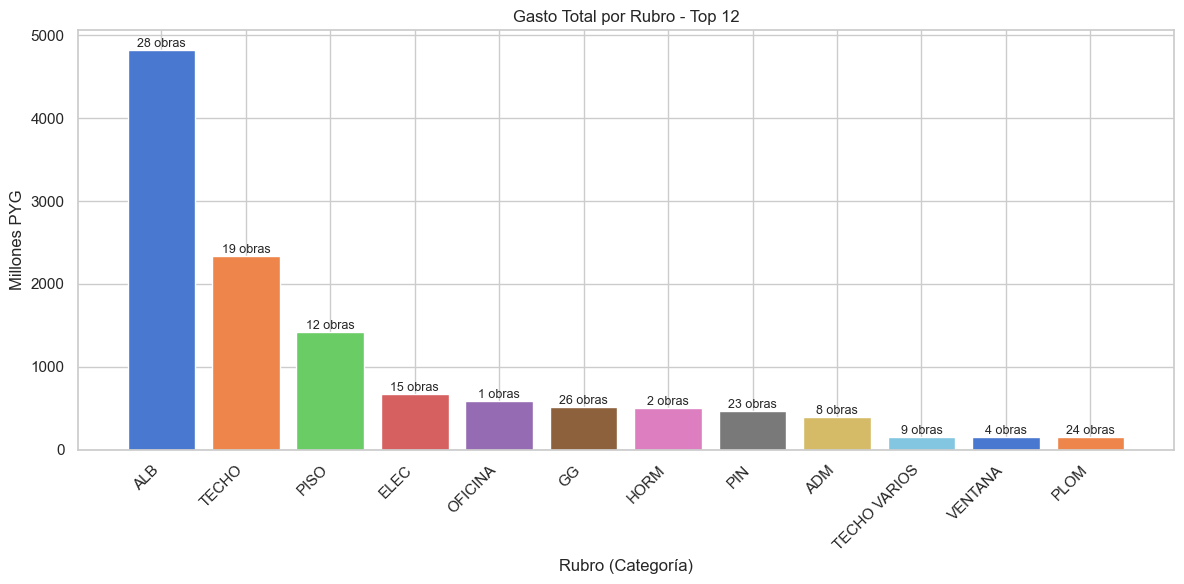

In [6]:
df_rubro_total = con.sql("""
    SELECT rubro_id, 
           sum(total_rubro) as total, 
           count(distinct obra_id) as qty_obras
    FROM main_marts.fct_costo_por_rubro
    GROUP BY rubro_id
    ORDER BY total DESC
    LIMIT 12
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_rubro_total['rubro_id'], df_rubro_total['total'] / 1e6, color=sns.color_palette('muted', len(df_rubro_total)))
ax.set_xlabel('Rubro (Categoría)')
ax.set_ylabel('Millones PYG')
ax.set_title('Gasto Total por Rubro - Top 12')
plt.xticks(rotation=45, ha='right')

for bar, obras in zip(bars, df_rubro_total['qty_obras']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{obras} obras', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Budget Deviation Analysis

In [7]:
df_desv = con.sql("""
    SELECT clasificacion, count(*) as qty, 
           sum(monto_presupuestado) as total_presupuestado,
           sum(monto_total_real) as total_real
    FROM main_marts.fct_desviacion_presupuesto
    WHERE clasificacion != 'SIN PRESUPUESTO'
    GROUP BY clasificacion
""").df()

if not df_desv.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors_map = {
        'DENTRO DE PRESUPUESTO': '#55A868',
        'LEVE DESVIO (+10%)': '#DD8452',
        'DESVIO SIGNIFICATIVO (>10%)': '#C44E52'
    }
    colors = [colors_map.get(c, '#8C8C8C') for c in df_desv['clasificacion']]
    
    axes[0].pie(df_desv['qty'], labels=df_desv['clasificacion'], autopct='%1.1f%%',
               colors=colors, startangle=90)
    axes[0].set_title('Distribución de Desviaciones')
    
    x = range(len(df_desv))
    width = 0.35
    axes[1].bar([i - width/2 for i in x], df_desv['total_presupuestado'] / 1e6, 
               width, label='Presupuestado', color='#4C72B0')
    axes[1].bar([i + width/2 for i in x], df_desv['total_real'] / 1e6,
               width, label='Real', color='#DD8452')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_desv['clasificacion'], rotation=30, ha='right')
    axes[1].set_ylabel('Millones PYG')
    axes[1].set_title('Presupuesto vs Real por Clasificación')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print('No budget deviation data available (presupuesto_cliente has minimal data).')

No budget deviation data available (presupuesto_cliente has minimal data).


## 7. Key Insights Summary

In [8]:
# Overall KPIs
kpis = con.sql("""
    SELECT
        (SELECT count(*) FROM main_staging.stg_dim_obras) as total_obras,
        (SELECT count(*) FROM main_staging.stg_fact_compra) as total_compras,
        (SELECT count(*) FROM main_staging.stg_fact_pago) as total_pagos,
        (SELECT sum(monto_total) FROM main_staging.stg_fact_compra) as total_materiales,
        (SELECT sum(monto_pago) FROM main_staging.stg_fact_pago) as total_mano_obra,
        (SELECT sum(monto_recibido) FROM main_staging.stg_fact_ingreso) as total_ingresos,
        (SELECT count(distinct proveedor_id) FROM main_staging.stg_fact_compra) as proveedores_activos,
        (SELECT count(distinct trabajador_id) FROM main_staging.stg_fact_pago) as trabajadores_activos
""").df()

print('=' * 60)
print('JS CONSTRUCCIONES - KEY PERFORMANCE INDICATORS')
print('=' * 60)
print(f"Total Obras:              {kpis['total_obras'][0]}")
print(f"Total Compras:            {kpis['total_compras'][0]:,}")
print(f"Total Pagos:              {kpis['total_pagos'][0]:,}")
print(f"Gasto Materiales:         {kpis['total_materiales'][0]/1e6:,.0f}M PYG")
print(f"Gasto Mano de Obra:       {kpis['total_mano_obra'][0]/1e6:,.0f}M PYG")
print(f"Ingresos Totales:         {kpis['total_ingresos'][0]/1e6:,.0f}M PYG")
print(f"Proveedores Activos:      {kpis['proveedores_activos'][0]}")
print(f"Trabajadores Activos:     {kpis['trabajadores_activos'][0]}")
print('=' * 60)

con.close()


JS CONSTRUCCIONES - KEY PERFORMANCE INDICATORS
Total Obras:              49
Total Compras:            5,669
Total Pagos:              2,030
Gasto Materiales:         7,073M PYG
Gasto Mano de Obra:       5,863M PYG
Ingresos Totales:         13,801M PYG
Proveedores Activos:      345
Trabajadores Activos:     118
